# 🎯 Job Interview Guide Workshop
## Weak Topic Deep-Dive: Logistic Regression Coefficients & Log-Odds

---

### 📋 About This Notebook

This notebook was generated based on your **quiz performance (14/15)**. You answered 14 questions correctly — strong work! Your one miss was:

> ❌ **Question 5:** Misidentified 1.8 (a logistic regression coefficient) as a decision threshold rather than a log-odds multiplier.

This is one of the **most common logistic regression interview mistakes** — and one of the easiest to fix once you deeply understand it.

---

### 🎯 Learning Objectives

By the end of this workshop, you will be able to:

1. Explain the difference between **probability**, **odds**, and **log-odds**
2. Correctly interpret logistic regression **coefficients** (`coef_`) and **intercept** (`intercept_`)
3. Understand why coefficients live in **log-odds space** and how to convert them to probability space
4. Explain the **decision threshold** — and why it is completely separate from the coefficients
5. Apply threshold manipulation to **increase recall** (as you correctly answered in Q15!)

---

### ⏱️ Estimated Time: 45–60 minutes

---
## 📦 Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


---
## 🧠 Part 1: The Three Concepts You Must Know

Before we touch any code, let's build the mental model. These three concepts form a **chain**:

```
  Probability  →  Odds  →  Log-Odds (Logit)
```

Logistic regression coefficients live at the **end** of this chain — in log-odds space.

---

### 1️⃣ Probability — What we intuitively understand

Probability is a number between 0 and 1.

- P(spam) = 0.9 → 90% chance this email is spam
- P(spam) = 0.1 → 10% chance this email is spam

The problem: probability is **bounded** (0 to 1). Linear regression can predict values outside this range. We need to work in an unbounded space.

---

### 2️⃣ Odds — A different way to express the same information

$$\text{Odds} = \frac{p}{1 - p}$$

Odds range from **0 to ∞** (still not unbounded in the negative direction).

- P = 0.5 → Odds = 1.0 ("even odds", 1-to-1)
- P = 0.75 → Odds = 3.0 ("3-to-1 in favor")
- P = 0.9 → Odds = 9.0

---

### 3️⃣ Log-Odds (Logit) — Where linear regression can live

$$\text{Log-Odds} = \log\left(\frac{p}{1-p}\right)$$

Log-odds range from **-∞ to +∞** — now we can use a linear model!

- P = 0.5 → Log-Odds = 0.0
- P = 0.75 → Log-Odds = 1.099
- P = 0.9 → Log-Odds = 2.197
- P = 0.1 → Log-Odds = -2.197

---

### 🔑 The Key Insight

Logistic regression fits this equation:

$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots$$

So **coefficients (β) directly describe changes in log-odds** — NOT changes in probability.

> 💡 **Interview Answer Template:**  
> *"A coefficient of 1.8 means that for a one-unit increase in that feature, the log-odds of the positive class increase by 1.8. To interpret this as a probability change, you would need to know the baseline probability and apply the sigmoid function — the relationship is nonlinear."

---
## 🔬 Part 2: Visualizing the Probability ↔ Log-Odds Relationship

C:\Users\Usuario\AppData\Local\Temp\ipykernel_27380\4168178129.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Usuario\Documents\Foundations\ML_Frameworks_JobInterviewGuide_Workshop\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


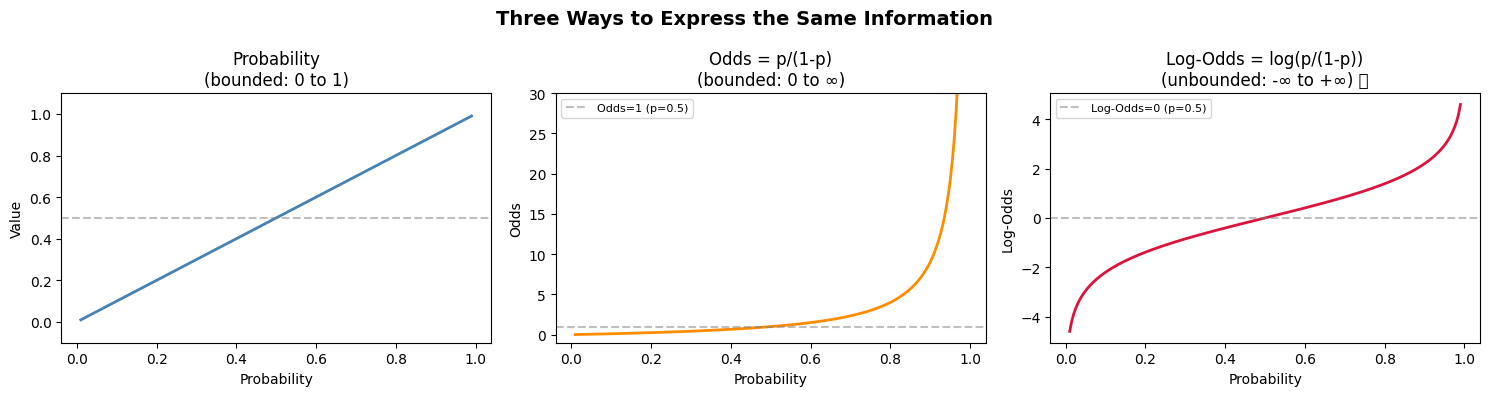


📊 Quick Reference Table:
 Probability |     Odds |   Log-Odds
--------------------------------------
        0.10 |    0.111 |     -2.197
        0.25 |    0.333 |     -1.099
        0.50 |    1.000 |      0.000
        0.75 |    3.000 |      1.099
        0.90 |    9.000 |      2.197


In [2]:
# ── Visualize the three representations side by side ──

p = np.linspace(0.01, 0.99, 200)
odds = p / (1 - p)
log_odds = np.log(odds)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Three Ways to Express the Same Information", fontsize=14, fontweight='bold')

# Plot 1: Probability (reference)
axes[0].plot(p, p, color='steelblue', linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Value")
axes[0].set_title("Probability\n(bounded: 0 to 1)")
axes[0].set_ylim(-0.1, 1.1)

# Plot 2: Odds
axes[1].plot(p, odds, color='darkorange', linewidth=2)
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Odds=1 (p=0.5)')
axes[1].set_xlabel("Probability")
axes[1].set_ylabel("Odds")
axes[1].set_title("Odds = p/(1-p)\n(bounded: 0 to ∞)")
axes[1].set_ylim(-1, 30)
axes[1].legend(fontsize=8)

# Plot 3: Log-Odds
axes[2].plot(p, log_odds, color='crimson', linewidth=2)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5, label='Log-Odds=0 (p=0.5)')
axes[2].set_xlabel("Probability")
axes[2].set_ylabel("Log-Odds")
axes[2].set_title("Log-Odds = log(p/(1-p))\n(unbounded: -∞ to +∞) ✅")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Sanity check table
print("\n📊 Quick Reference Table:")
print(f"{'Probability':>12} | {'Odds':>8} | {'Log-Odds':>10}")
print("-" * 38)
for prob in [0.1, 0.25, 0.5, 0.75, 0.9]:
    o = prob / (1 - prob)
    lo = np.log(o)
    print(f"{prob:>12.2f} | {o:>8.3f} | {lo:>10.3f}")

---
## 🧪 Part 3: Training a Logistic Regression & Reading the Coefficients

Let's use a realistic scenario: **predicting email spam** based on two features:
- `exclamation_count` — number of exclamation marks
- `word_count` — total words in the email (more words → less likely spam)

In [3]:
# ── Generate synthetic email dataset ──

n = 500

# Legitimate emails: few exclamations, more words
legit_excl = np.random.poisson(lam=1.0, size=n//2)
legit_words = np.random.normal(loc=120, scale=30, size=n//2).clip(20)

# Spam emails: many exclamations, fewer words
spam_excl = np.random.poisson(lam=5.0, size=n//2)
spam_words = np.random.normal(loc=60, scale=20, size=n//2).clip(10)

X = np.vstack([
    np.column_stack([legit_excl, legit_words]),
    np.column_stack([spam_excl, spam_words])
])
y = np.array([0] * (n//2) + [1] * (n//2))  # 0 = legit, 1 = spam

# Create DataFrame for readability
df = pd.DataFrame(X, columns=['exclamation_count', 'word_count'])
df['is_spam'] = y

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass balance:")
print(df['is_spam'].value_counts())

Dataset shape: (500, 3)

First 5 rows:
   exclamation_count  word_count  is_spam
0                1.0  116.672042        0
1                2.0  149.289274        0
2                0.0   76.414516        0
3                0.0  143.520192        0
4                3.0  115.268281        0

Class balance:
is_spam
0    250
1    250
Name: count, dtype: int64


In [4]:
# ── Train the Logistic Regression model ──

X_train, X_test, y_train, y_test = train_test_split(
    df[['exclamation_count', 'word_count']], df['is_spam'],
    test_size=0.2, random_state=42, stratify=df['is_spam']
)

# Scale features (important for coefficient interpretability!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Model trained!")
print(f"\n📐 Intercept (β₀):         {model.intercept_[0]:.4f}")
print(f"📐 Coef: exclamation_count: {model.coef_[0][0]:.4f}")
print(f"📐 Coef: word_count:        {model.coef_[0][1]:.4f}")

✅ Model trained!

📐 Intercept (β₀):         0.2872
📐 Coef: exclamation_count: 3.2322
📐 Coef: word_count:        -2.4606


### 🗣️ Instructor Talking Point: How to Interpret These Coefficients

> **Intercept (β₀):** The log-odds of spam when all features are at their mean value (since we scaled). A negative intercept means the baseline probability leans toward the negative class (not spam).

> **exclamation_count coefficient (positive):** Each 1 standard deviation increase in exclamation count **increases the log-odds of spam** by this amount. Positive → pushes toward spam.

> **word_count coefficient (negative):** Each 1 standard deviation increase in word count **decreases the log-odds of spam** by this amount. Negative → pushes away from spam.

**⚠️ What the coefficient is NOT:**
- It is NOT the probability increase
- It is NOT the decision threshold  
- It is NOT the accuracy contribution of that feature

In [5]:
# ── Demonstrate the log-odds → probability conversion ──

def sigmoid(z):
    """Convert log-odds to probability."""
    return 1 / (1 + np.exp(-z))

intercept = model.intercept_[0]
coef_excl = model.coef_[0][0]
coef_words = model.coef_[0][1]

# Example email: average exclamations, average word count → scaled = (0, 0)
log_odds_baseline = intercept + coef_excl * 0 + coef_words * 0
prob_baseline = sigmoid(log_odds_baseline)

# Example email: 1 std above average exclamations, average word count → scaled = (1, 0)
log_odds_high_excl = intercept + coef_excl * 1 + coef_words * 0
prob_high_excl = sigmoid(log_odds_high_excl)

print("📧 Example Calculation: Effect of Exclamation Count")
print("=" * 55)
print(f"Baseline (avg exclamations):")
print(f"  Log-odds = {log_odds_baseline:.4f}")
print(f"  P(spam)  = {prob_baseline:.4f} ({prob_baseline*100:.1f}%)")
print()
print(f"High exclamations (+1 std dev):")
print(f"  Log-odds = {log_odds_high_excl:.4f}")
print(f"  P(spam)  = {prob_high_excl:.4f} ({prob_high_excl*100:.1f}%)")
print()
print(f"Log-odds change: {coef_excl:.4f} (the coefficient itself)")
print(f"Probability change: {(prob_high_excl - prob_baseline)*100:.1f}% ← NOT the same as the coefficient!")

📧 Example Calculation: Effect of Exclamation Count
Baseline (avg exclamations):
  Log-odds = 0.2872
  P(spam)  = 0.5713 (57.1%)

High exclamations (+1 std dev):
  Log-odds = 3.5195
  P(spam)  = 0.9712 (97.1%)

Log-odds change: 3.2322 (the coefficient itself)
Probability change: 40.0% ← NOT the same as the coefficient!


---
## ✏️ Part 4: Exercises — Fill in the TODOs

Complete the exercises below. Answers are in the cells after each one.

### Exercise 1: Odds Ratio Interpretation

A useful trick: `exp(coefficient)` gives you the **odds ratio** — the multiplicative factor by which the odds change for a 1-unit increase in that feature.

If `exp(coef) = 2.5`, it means a 1-unit increase in that feature **multiplies the odds by 2.5**.

In [6]:
# TODO: Calculate the odds ratio for each feature
# Hint: Use np.exp() on the coefficients

odds_ratio_excl = None   # TODO: replace with np.exp(coef_excl)
odds_ratio_words = None  # TODO: replace with np.exp(coef_words)

# TODO: Print a sentence interpreting each odds ratio
# e.g., "A 1 std dev increase in exclamation count multiplies the odds of spam by X"

print("Odds ratio for exclamation_count:", odds_ratio_excl)
print("Odds ratio for word_count:", odds_ratio_words)

Odds ratio for exclamation_count: None
Odds ratio for word_count: None


In [7]:
# ✅ ANSWER - Exercise 1
odds_ratio_excl = np.exp(coef_excl)
odds_ratio_words = np.exp(coef_words)

print(f"Odds ratio for exclamation_count: {odds_ratio_excl:.3f}")
print(f"  → A 1 std dev increase in exclamation count multiplies the odds of spam by {odds_ratio_excl:.2f}x")
print()
print(f"Odds ratio for word_count: {odds_ratio_words:.3f}")
print(f"  → A 1 std dev increase in word count multiplies the odds of spam by {odds_ratio_words:.2f}x")
print(f"  → Since this is < 1, longer emails are less likely to be spam")

Odds ratio for exclamation_count: 25.336
  → A 1 std dev increase in exclamation count multiplies the odds of spam by 25.34x

Odds ratio for word_count: 0.085
  → A 1 std dev increase in word count multiplies the odds of spam by 0.09x
  → Since this is < 1, longer emails are less likely to be spam


### Exercise 2: The Decision Threshold — Separate from Coefficients

The default threshold is **0.5**: predict spam if P(spam) ≥ 0.5.

But this threshold is **completely separate** from the coefficients — you can change it after training without retraining the model.

In [8]:
# Get predicted probabilities (not hard class predictions)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # P(spam) for each test email

# Default threshold = 0.5
y_pred_default = (y_proba >= 0.5).astype(int)

print("📊 Performance at default threshold (0.5):")
print(classification_report(y_test, y_pred_default, target_names=['Legit', 'Spam']))

# TODO: Try a lower threshold (e.g., 0.3) to increase spam recall
# This is exactly what you recommended in Question 15!

threshold_low = 0.3
y_pred_low = None  # TODO: replace with (y_proba >= threshold_low).astype(int)

print(f"\n📊 Performance at lower threshold ({threshold_low}):")
# TODO: Print classification report for y_pred_low

📊 Performance at default threshold (0.5):
              precision    recall  f1-score   support

       Legit       0.92      0.94      0.93        50
        Spam       0.94      0.92      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100


📊 Performance at lower threshold (0.3):


In [9]:
# ✅ ANSWER - Exercise 2
threshold_low = 0.3
y_pred_low = (y_proba >= threshold_low).astype(int)

print(f"📊 Performance at lower threshold ({threshold_low}):")
print(classification_report(y_test, y_pred_low, target_names=['Legit', 'Spam']))

print("💡 Observation: Lowering the threshold increases Spam RECALL")
print("   (we catch more spam) at the cost of lower PRECISION (more false alarms).")
print("   The coefficients did NOT change — only the decision boundary moved.")

📊 Performance at lower threshold (0.3):
              precision    recall  f1-score   support

       Legit       0.96      0.94      0.95        50
        Spam       0.94      0.96      0.95        50

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100

💡 Observation: Lowering the threshold increases Spam RECALL
   (we catch more spam) at the cost of lower PRECISION (more false alarms).
   The coefficients did NOT change — only the decision boundary moved.


### Exercise 3: Precision-Recall Trade-off Curve

Visualize how precision and recall change as you vary the threshold from 0.1 to 0.9.

In [10]:
# TODO: Complete this code to plot precision and recall across thresholds
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.1, 0.9, 50)
precisions = []
recalls = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    # TODO: append precision_score and recall_score to their lists
    # Hint: use zero_division=0 parameter to handle edge cases
    pass

# TODO: Plot precisions and recalls vs thresholds
# Label axes and add a legend
print("TODO: Complete the plotting code above")

TODO: Complete the plotting code above


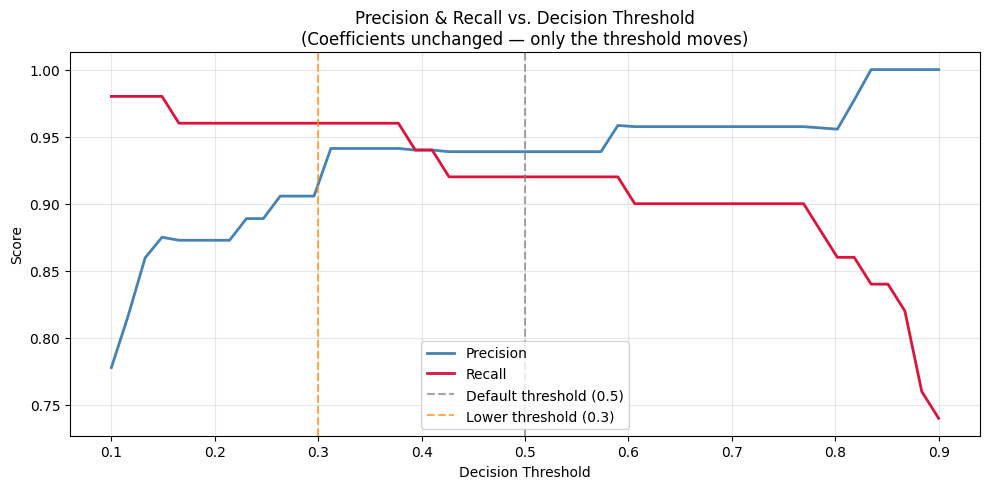

💡 Key takeaway: The threshold is a POST-TRAINING decision.
   The model's learned coefficients never change — you're just moving
   the line that converts probabilities into class predictions.


In [11]:
# ✅ ANSWER - Exercise 3
thresholds = np.linspace(0.1, 0.9, 50)
precisions = []
recalls = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', color='steelblue', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', color='crimson', linewidth=2)
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
plt.axvline(0.3, color='darkorange', linestyle='--', alpha=0.7, label='Lower threshold (0.3)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs. Decision Threshold\n(Coefficients unchanged — only the threshold moves)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Key takeaway: The threshold is a POST-TRAINING decision.")
print("   The model's learned coefficients never change — you're just moving")
print("   the line that converts probabilities into class predictions.")

---
## 🗺️ Part 5: Complete Mental Map — Putting It All Together

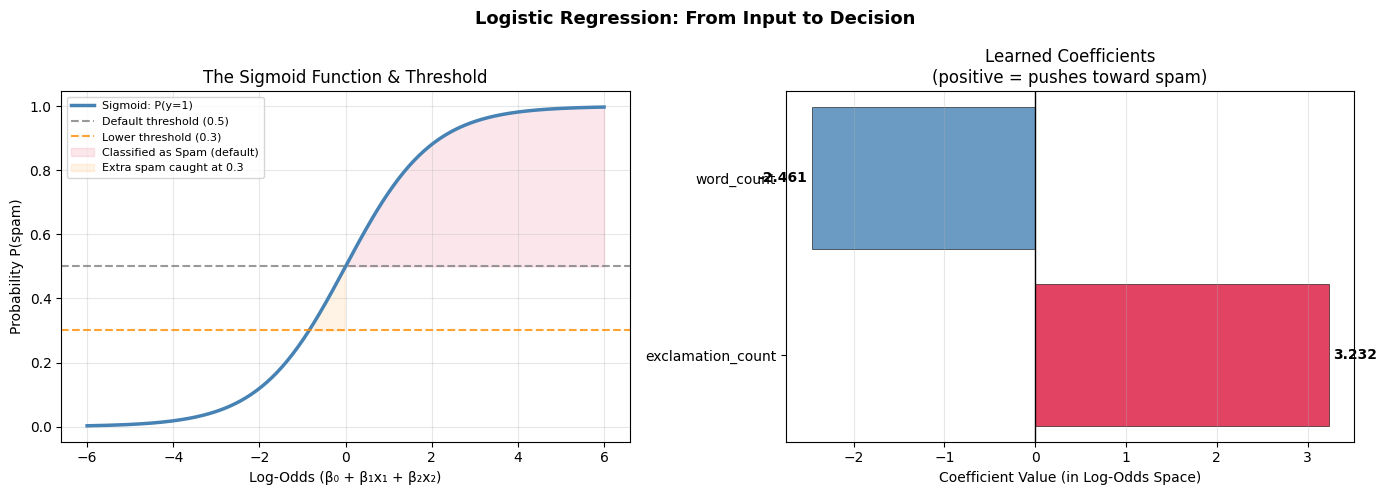


📌 Summary of the complete pipeline:
  1. Input features (x₁, x₂) →
  2. Linear combination → Log-Odds = β₀ + β₁x₁ + β₂x₂
  3. Sigmoid function → Probability P(spam) ∈ [0, 1]
  4. Threshold comparison → Class prediction (0 or 1)
  ⚠️  Coefficients live in Step 2. Threshold lives in Step 4. They are independent!


In [12]:
# ── Full end-to-end diagram of logistic regression internals ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression: From Input to Decision', fontsize=13, fontweight='bold')

# Left: sigmoid curve with threshold lines
z = np.linspace(-6, 6, 300)
prob = 1 / (1 + np.exp(-z))

axes[0].plot(z, prob, color='steelblue', linewidth=2.5, label='Sigmoid: P(y=1)')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.8, label='Default threshold (0.5)')
axes[0].axhline(0.3, color='darkorange', linestyle='--', alpha=0.8, label='Lower threshold (0.3)')
axes[0].fill_between(z, prob, 0.5, where=(prob >= 0.5), alpha=0.1, color='crimson', label='Classified as Spam (default)')
axes[0].fill_between(z, prob, 0.3, where=(prob >= 0.3) & (prob < 0.5), alpha=0.1, color='darkorange', label='Extra spam caught at 0.3')
axes[0].set_xlabel('Log-Odds (β₀ + β₁x₁ + β₂x₂)')
axes[0].set_ylabel('Probability P(spam)')
axes[0].set_title('The Sigmoid Function & Threshold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: coefficient effects
features = ['exclamation_count', 'word_count']
coefs = model.coef_[0]
colors = ['crimson' if c > 0 else 'steelblue' for c in coefs]

bars = axes[1].barh(features, coefs, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Coefficient Value (in Log-Odds Space)')
axes[1].set_title('Learned Coefficients\n(positive = pushes toward spam)')

for bar, coef in zip(bars, coefs):
    axes[1].text(coef + (0.05 if coef > 0 else -0.05), bar.get_y() + bar.get_height()/2,
                f'{coef:.3f}', va='center', ha='left' if coef > 0 else 'right', fontweight='bold')

axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📌 Summary of the complete pipeline:")
print("  1. Input features (x₁, x₂) →")
print("  2. Linear combination → Log-Odds = β₀ + β₁x₁ + β₂x₂")
print("  3. Sigmoid function → Probability P(spam) ∈ [0, 1]")
print("  4. Threshold comparison → Class prediction (0 or 1)")
print("  ⚠️  Coefficients live in Step 2. Threshold lives in Step 4. They are independent!")

---
## ⚡ Part 6: Quick Interview Prep — Flash Cards

Run this cell for a quick self-quiz on the key concepts.

In [13]:
flash_cards = [
    {
        "q": "Q: A logistic regression coefficient is 2.3. What does this mean?",
        "a": "A: For a 1-unit increase in that feature, the LOG-ODDS of the positive class \n   increase by 2.3. It does NOT mean the probability increases by 2.3."
    },
    {
        "q": "Q: How do you convert a coefficient to an odds ratio?",
        "a": "A: exp(coefficient). If exp(2.3) = 9.97, a 1-unit increase multiplies the odds \n   of the positive class by ~10x."
    },
    {
        "q": "Q: What is the decision threshold and how is it related to the coefficients?",
        "a": "A: The threshold converts a probability into a class label (default: 0.5). \n   It is completely INDEPENDENT of the learned coefficients. \n   You can change the threshold after training without retraining."
    },
    {
        "q": "Q: Why does logistic regression use log-odds instead of probability directly?",
        "a": "A: Probability is bounded [0,1] — you can't fit a linear model to it directly. \n   Log-odds are unbounded (-∞ to +∞), so a linear equation can model them."
    },
    {
        "q": "Q: How would you increase recall for the positive class after training?",
        "a": "A: Lower the decision threshold below 0.5. This makes the model more aggressive \n   at predicting the positive class, catching more true positives \n   (at the cost of more false positives / lower precision)."
    }
]

print("=" * 60)
print("  🃏 INTERVIEW FLASH CARDS — Logistic Regression")
print("=" * 60)
for i, card in enumerate(flash_cards, 1):
    print(f"\n[{i}/{len(flash_cards)}] {card['q']}")
    print(f"\n{card['a']}")
    print("-" * 60)

  🃏 INTERVIEW FLASH CARDS — Logistic Regression

[1/5] Q: A logistic regression coefficient is 2.3. What does this mean?

A: For a 1-unit increase in that feature, the LOG-ODDS of the positive class 
   increase by 2.3. It does NOT mean the probability increases by 2.3.
------------------------------------------------------------

[2/5] Q: How do you convert a coefficient to an odds ratio?

A: exp(coefficient). If exp(2.3) = 9.97, a 1-unit increase multiplies the odds 
   of the positive class by ~10x.
------------------------------------------------------------

[3/5] Q: What is the decision threshold and how is it related to the coefficients?

A: The threshold converts a probability into a class label (default: 0.5). 
   It is completely INDEPENDENT of the learned coefficients. 
   You can change the threshold after training without retraining.
------------------------------------------------------------

[4/5] Q: Why does logistic regression use log-odds instead of probability direc

---
## 📝 Part 7: Reflection Prompt

> **Take 5 minutes to answer these questions in your own words (write below or in a separate doc):**
>
> 1. Before this workshop, what did you think a logistic regression coefficient represented? How has that understanding changed?
>
> 2. In your own words, explain the chain: **probability → odds → log-odds → coefficient**. Could you explain this to a non-technical stakeholder?
>
> 3. In the spam example, if you had to deploy this model in a high-stakes environment (e.g., corporate email filtering where blocking a legitimate email has real business costs), would you raise or lower the threshold from 0.5? Why?
>
> 4. What is the one sentence you would say in an interview if asked *"What does a coefficient of 1.8 mean in your logistic regression model?"*

---

**Your answers:**

*(Double-click this cell to edit)*

1. 

2. 

3. 

4. 

---
## 🏁 Summary

| Concept | Key Takeaway |
|---|---|
| **Log-Odds** | The unbounded space where linear regression lives inside logistic regression |
| **Coefficient** | Change in log-odds per 1-unit increase in feature — NOT a probability change |
| **Intercept** | Baseline log-odds when all features are zero (or at mean, if scaled) |
| **Odds Ratio** | `exp(coef)` — multiplicative factor on the odds for a 1-unit increase |
| **Sigmoid** | Converts log-odds → probability. The model's output before thresholding |
| **Threshold** | Converts probability → class label. **Independent of coefficients.** Tune post-training |
| **Lower threshold** | ↑ Recall, ↓ Precision — use when missing positives is costly (fraud, medical) |
| **Higher threshold** | ↑ Precision, ↓ Recall — use when false alarms are costly (spam to inbox) |

---

### 🎯 You're ready to nail this topic in your interview. Good luck! 🚀

*Generated based on quiz performance — JobInterviewGuide_Workshop*